## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs.

You have several choices here:

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [2]:
import string
import os


In [3]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # если доступно GPU, вычисления будут производиться там

# Устанавливаем фиксированное зерно для случайных чисел
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [5]:
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

--2024-11-17 06:21:41--  https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks/lab02_deep_learning/sonnets.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 119748 (117K) [text/plain]
Saving to: ‘sonnets.txt’

sonnets.txt         100%[===================>] 116.94K  --.-KB/s    in 0.03s   

2024-11-17 06:21:42 (4.49 MB/s) - ‘sonnets.txt’ saved [119748/119748]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [6]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here

text[0] = ' ' + text[0]  # Добавляем пробел в начале первой строки, чтобы избежать слияния слов
text_combined = ' '.join(text).lower()  # Объединяем все строки в одну и нормализуем (приводим к нижнему регистру)
text_lines = text_combined.split('\n')  # Разделяем текст по символу новой строки
text = text_combined.replace('\n', '')

assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

OK!


In [7]:
# это же стихи, поэтому лучше поступить иначе - сохранить переход на новую строку как токен и убрать римские цифры, нумирующие сонеты
#import re

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()
TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616
# уберем пробелы в начале строк
text = [line.lstrip() for line in text]
# Объединяем строки в один текст, сохраняя \n
text = ''.join(text).lower()
# Удаляем римские цифры
text = re.sub(r'(^|\n)\s*[ivxlcdm]+\s+', '\n', text)

print(text[:1000])  # Выводим первые 1000 символов


from fairest creatures we desire increase,
that thereby beauty's rose might never die,
but as the riper should by time decease,
his tender heir might bear his memory:
but thou, contracted to thine own bright eyes,
feed'st thy light's flame with self-substantial fuel,
making a famine where abundance lies,
thy self thy foe, to thy sweet self too cruel:
thou that art now the world's fresh ornament,
and only herald to the gaudy spring,
within thine own bud buriest thy content,
and tender churl mak'st waste in niggarding:
pity the world, or else this glutton be,
to eat the world's due, by the grave and thee.
when forty winters shall besiege thy brow,
and dig deep trenches in thy beauty's field,
thy youth's proud livery so gazed on now,
will be a tatter'd weed of small worth held:
then being asked, where all thy beauty lies,
where all the treasure of thy lusty days;
to say, within thine own deep sunken eyes,
were an all-eating shame, and thriftless praise.
how much more praise deserv'd thy b

### Data loading: "Евгений Онегин"


In [ ]:
# !wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt

# with open('onegin.txt', 'r') as iofile:
#     text = iofile.readlines()

# text = [x.replace('\t\t', '') for x in text]

--2024-11-11 19:20:51--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.04s   

2024-11-11 19:20:51 (6.79 MB/s) - ‘onegin.txt’ saved [262521/262521]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [ ]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here


Put all the characters, that you've seen in the text, into variable `tokens`.

In [8]:
tokens = sorted(set(text))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [9]:
# dict <index>:<char>
# Your great code here

token_to_idx = {char: idx for idx, char in enumerate(tokens)}  # Словарь: символ - индекс

# dict <char>:<index>
# Your great code here
idx_to_token = {idx: char for idx, char in enumerate(tokens)}  # Словарь: индекс - символ

print("Tokens:", tokens)
print("Token to index:", token_to_idx)
print("Index to token:", idx_to_token)

Tokens: ['\n', ' ', '!', "'", '(', ')', ',', '-', '.', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Token to index: {'\n': 0, ' ': 1, '!': 2, "'": 3, '(': 4, ')': 5, ',': 6, '-': 7, '.': 8, ':': 9, ';': 10, '?': 11, 'a': 12, 'b': 13, 'c': 14, 'd': 15, 'e': 16, 'f': 17, 'g': 18, 'h': 19, 'i': 20, 'j': 21, 'k': 22, 'l': 23, 'm': 24, 'n': 25, 'o': 26, 'p': 27, 'q': 28, 'r': 29, 's': 30, 't': 31, 'u': 32, 'v': 33, 'w': 34, 'x': 35, 'y': 36, 'z': 37}
Index to token: {0: '\n', 1: ' ', 2: '!', 3: "'", 4: '(', 5: ')', 6: ',', 7: '-', 8: '.', 9: ':', 10: ';', 11: '?', 12: 'a', 13: 'b', 14: 'c', 15: 'd', 16: 'e', 17: 'f', 18: 'g', 19: 'h', 20: 'i', 21: 'j', 22: 'k', 23: 'l', 24: 'm', 25: 'n', 26: 'o', 27: 'p', 28: 'q', 29: 'r', 30: 's', 31: 't', 32: 'u', 33: 'v', 34: 'w', 35: 'x', 36: 'y', 37: 'z'}


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

In [14]:
#import numpy as np

vocab_size = len(tokens)    # размер словаря (число уникальных токенов - в нашем случае символов)

# Преобразование текста в матрицу one-hot encoding
def one_hot_encode(text, vocab_size):
    one_hot_matrix = np.zeros((len(text), vocab_size), dtype=np.float32)
    for i, char in enumerate(text): # распаковываем кортеж
        one_hot_matrix[i, token_to_idx[char]] = 1 # Заполняем единицей позицию вектора соответствующего символа
    return one_hot_matrix


### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [15]:
# Построение модели (Vanilla RNN) на основе nn.RNN
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size): # конструктор
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size # размер скрытого состояния
        # слой RNN, который и обрабатывает последовательность
        self.rnn = nn.RNN(input_size=vocab_size, hidden_size=hidden_size, batch_first=True)
        # полносвязный слой, который преобразует скрытое состояние RNN в предсказания для каждого символа из словаря.
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x): # прямой проход через модель
        out, _ = self.rnn(x) # прогоняет входные данные через слой RNN
        out = self.fc(out[:, -1, :])  # Используем выход на последнем шаге в каждом батче
        return out # возвращает предсказания для каждого символа из словаря на основе последнего шага последовательности

In [16]:
# Параметры модели
hidden_size = 128
model = CharRNN(vocab_size, hidden_size).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Plot the loss function (axis X: number of epochs, axis Y: loss function).

In [17]:
# Создание обучающих данных
SEQ_LENGTH = 40
STEP = 3
sequences = []
next_chars = [] # метки для последовальности - "правильный" следующий символ

for i in range(0, len(text) - SEQ_LENGTH, STEP):
    sequences.append(text[i: i + SEQ_LENGTH]) # создается подстрока и добавляется в список sequences
    next_chars.append(text[i + SEQ_LENGTH]) # следующий симвод добавляется в список next_chars, который будет содержать "правильный" следующий символ для каждой из последовательностей

# создаем матрицы для хранения входных и выходных данных (X и y) в формате one-hot векторов
X = np.zeros((len(sequences), SEQ_LENGTH, vocab_size), dtype=np.float32)
y = np.zeros((len(sequences), vocab_size), dtype=np.float32)

for i, seq in enumerate(sequences): # распаковываем кортеж
    X[i] = one_hot_encode(seq, vocab_size)  # Применяем one-hot encoding к последовательности
    y[i, token_to_idx[next_chars[i]]] = 1   # Метка - следующий символ после последовательности

# Преобразуем в тензоры PyTorch
X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)

In [18]:
# Обучение модели
EPOCHS = 200
BATCH_SIZE = 2048

history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    # Обработка батчей и вычисление ошибки
    for batch_idx in range(0, len(X), BATCH_SIZE): # текущий индекс начала батча,
        # Разбиение на батчи
        input_batch = X[batch_idx: batch_idx + BATCH_SIZE]
        target_batch = y[batch_idx: batch_idx + BATCH_SIZE]

        # Обучение модели
        optimizer.zero_grad() # обнуление градиента
        outputs = model(input_batch) # предсказание модели на основе текущего input_batch, model(input_batch) вызывает метод forward внутри класса CharRNN.

        loss = loss_func(outputs, target_batch) # функция потерь
        loss.backward() # backpropagation
        optimizer.step() # оптимизатор обновляет параметры модели на основе вычисленных градиентов

        total_loss += loss.item()

    history.append(total_loss)

    # Визуализация прогресса
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch + 1}/{EPOCHS}], Loss: {total_loss:.4f}')
torch.save(model, 'vRNN.pth')

Epoch [5/200], Loss: 47.0580
Epoch [10/200], Loss: 41.0719
Epoch [15/200], Loss: 37.5851
Epoch [20/200], Loss: 35.7760
Epoch [25/200], Loss: 34.7299
Epoch [30/200], Loss: 33.8592
Epoch [35/200], Loss: 33.0920
Epoch [40/200], Loss: 32.3840
Epoch [45/200], Loss: 31.7756
Epoch [50/200], Loss: 31.2735
Epoch [55/200], Loss: 30.7565
Epoch [60/200], Loss: 30.2495
Epoch [65/200], Loss: 29.8030
Epoch [70/200], Loss: 29.3834
Epoch [75/200], Loss: 28.9849
Epoch [80/200], Loss: 28.9319
Epoch [85/200], Loss: 28.5565
Epoch [90/200], Loss: 27.9938
Epoch [95/200], Loss: 27.5021
Epoch [100/200], Loss: 27.1006
Epoch [105/200], Loss: 26.7251
Epoch [110/200], Loss: 26.3484
Epoch [115/200], Loss: 25.9710
Epoch [120/200], Loss: 25.5943
Epoch [125/200], Loss: 25.2571
Epoch [130/200], Loss: 25.1647
Epoch [135/200], Loss: 24.7810
Epoch [140/200], Loss: 24.7099
Epoch [145/200], Loss: 24.6395
Epoch [150/200], Loss: 24.1268
Epoch [155/200], Loss: 24.0019
Epoch [160/200], Loss: 24.4995
Epoch [165/200], Loss: 24.13

In [19]:
#torch.save(model, 'vRNN.pth')

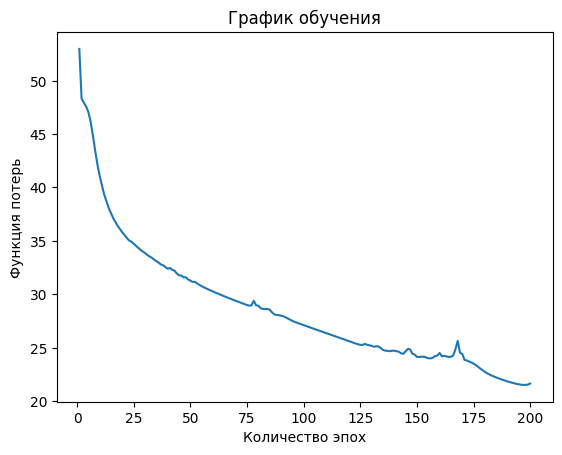

In [20]:
# Your plot code here

plt.plot(range(1, EPOCHS + 1), history)
plt.xlabel('Количество эпох')
plt.ylabel('Функция потерь')
plt.title('График обучения')
plt.show()


In [ ]:
model = torch.load('vRNN', weights_only=False)
# model.eval()

In [21]:
def generate_text(model, seed_text, num_generate=500, temperature=1.0, max_line_length=80):
    model.eval()  # Устанавливаем модель в режим оценки (без обучения)

    generated_text = input_seq = seed_text.lower()

    # Преобразуем в one-hot encoding
    input_one_hot = one_hot_encode(input_seq, vocab_size)
    input_tensor = torch.tensor(input_one_hot, dtype=torch.float32).unsqueeze(0).to(device)  # Добавляем размерность батча

    # Генерация текста
    for _ in range(num_generate):
        with torch.no_grad():  # Не обновляем градиенты
            output = model(input_tensor)  # Прогоняем модель
            output = output.squeeze(0)  # Убираем лишнюю размерность (ось)

            # Применяем temperature для регулировки вероятностей
            output = output / temperature
            probabilities = torch.nn.functional.softmax(output, dim=0).cpu().numpy()

            # Выбираем символ с вероятностью
            next_idx = np.random.choice(len(probabilities), p=probabilities)
            next_char = idx_to_token[next_idx]

            # Добавляем новый символ в сгенерированный текст
            generated_text += next_char

            # Обновляем входную последовательность для следующего шага
            input_seq = input_seq[1:] + next_char  # Сдвигаем последовательность
            input_one_hot = one_hot_encode(input_seq, vocab_size)
            input_tensor = torch.tensor(input_one_hot, dtype=torch.float32).unsqueeze(0).to(device)  # Добавляем размерность батча

    return generated_text

seed_text = "To be or not to be"
print(generate_text(model, seed_text, num_generate=400, temperature=0.8))

to be or not to beiven ighee.
whe foom dagh evenes's,
and cofter heavers, and inke tho helest,
and in ofo thaus, the eckeet, of levest.
undst is mare all stist,
and not if this of my wil,
thoughins if show, lots faness agead,
and past thou all whing,
the buctoun with thise.
thast oun ond you herfirge
and encest my seaded;
but makuther ever with mence ato,
the ispeakero efarse,
though chait, sand in the sturne.
whos


In [ ]:
#def generate_sample(char_rnn, seed_phrase=' Hello', max_length=MAX_LENGTH, temperature=1.0):
    '''
    ### Disclaimer: this is an example function for text generation.
    ### You can either adapt it in your code or create your own function

    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
        smaller temperature converges to the single most likely output.

    Be careful with the model output. This model waits logits (not probabilities/log-probabilities)
    of the next symbol.
    '''

    # x_sequence = [token_to_id[token] for token in seed_phrase]
    # x_sequence = torch.tensor([[x_sequence]], dtype=torch.int64)
    # hid_state = char_rnn.initial_state(batch_size=1)

    # #feed the seed phrase, if any
    # for i in range(len(seed_phrase) - 1):
    #     print(x_sequence[:, -1].shape, hid_state.shape)
    #     out, hid_state = char_rnn(x_sequence[:, i], hid_state)

    # #start generating
    # for _ in range(max_length - len(seed_phrase)):
    #     print(x_sequence.shape, x_sequence, hid_state.shape)
    #     out, hid_state = char_rnn(x_sequence[:, -1], hid_state)
    #     # Be really careful here with the model output
    #     p_next = F.softmax(out / temperature, dim=-1).data.numpy()[0]

    #     # sample next token and push it back into x_sequence
    #     print(p_next.shape, len(tokens))
    #     next_ix = np.random.choice(len(tokens), p=p_next)
    #     next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
    #     print(x_sequence.shape, next_ix.shape)
    #     x_sequence = torch.cat([x_sequence, next_ix], dim=1)

    # return ''.join([tokens[ix] for ix in x_sequence.data.numpy()[0]])

In [ ]:
# An example of generated text.
#print(generate_sample(length=500, temperature=0.2))


### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [22]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers=2): # конструктор
        super(CharLSTM, self).__init__()
        self.hidden_size = hidden_size # размер скрытого состояния
        self.num_layers = num_layers # количество слоев

        # LSTM слой
        self.lstm = nn.LSTM(input_size=vocab_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        # Полносвязный слой для предсказания следующего символа -
        # он преобразует выход LSTM (размер hidden_size) в размерность, соответствующую размеру словаря (vocab_size) - предсказывает вероятность каждого символа.
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden_state=None):
        # Прогоняем данные через LSTM
        out, hidden_state = self.lstm(x, hidden_state)  # hidden_state - это кортеж (h, c):
        # h — скрытое состояние, которое сохраняет информацию о предыдущих шагах
        # c — ячейка состояния, которая хранит долгосрочную информацию и обновляется с каждым  шагом.

        # Применяем линейный слой к последнему выходу LSTM
        out = self.fc(out[:, -1, :])  # Используем последний выход LSTM по каждому элементу в батче для предсказания
        # это важно, так как мы прогнозируем следующий символ на основе всей последовательности
        # self.fc: пропускаем этот выход через полносвязный слой, чтобы получить вероятности для каждого символа из словаря

        return out, hidden_state # Возвращаем предсказания (out) и обновленное скрытое состояние (hidden_state) и передаем на следующий временной шаг

In [23]:
# Параметры модели
hidden_size = 128
num_layers = 2  # Количество слоев LSTM
model = CharLSTM(vocab_size, hidden_size, num_layers).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
# Параметры обучения
EPOCHS = 200 # экспериментально установлено, что 200 эпох для данной модели достаточно для качественной генерации текста
BATCH_SIZE = 2048

history = []

# обучающие данные были созданы ранее

# Обучение модели
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_idx in range(0, len(X), BATCH_SIZE):
        # Разбиение на батчи
        input_batch = X[batch_idx: batch_idx + BATCH_SIZE]
        target_batch = y[batch_idx: batch_idx + BATCH_SIZE]

        # Инициализация скрытого состояния (обнуляется для каждого батча)
        hidden_state = None

        optimizer.zero_grad()  # обнуление градиента
        outputs, hidden_state = model(input_batch, hidden_state)  # Прогоняем через модель

        # Отсоединение hidden_state для предотвращения накопления градиентов
        hidden_state = tuple(h.detach() for h in hidden_state)

        loss = loss_func(outputs, target_batch)
        loss.backward()  # backpropagation
        optimizer.step()  # оптимизатор обновляет параметры модели

        total_loss += loss.item()

    history.append(total_loss)

    # Визуализация прогресса
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch + 1}/{EPOCHS}], Loss: {total_loss:.4f}')

torch.save(model, 'LTSM.pth')

Epoch [5/200], Loss: 48.2156
Epoch [10/200], Loss: 45.6749
Epoch [15/200], Loss: 39.7926
Epoch [20/200], Loss: 37.0361
Epoch [25/200], Loss: 35.7250
Epoch [30/200], Loss: 34.4764
Epoch [35/200], Loss: 33.6454
Epoch [40/200], Loss: 32.6122
Epoch [45/200], Loss: 31.7068
Epoch [50/200], Loss: 30.9402
Epoch [55/200], Loss: 30.2299
Epoch [60/200], Loss: 29.4537
Epoch [65/200], Loss: 28.8204
Epoch [70/200], Loss: 28.2279
Epoch [75/200], Loss: 27.5313
Epoch [80/200], Loss: 26.9920
Epoch [85/200], Loss: 26.2084
Epoch [90/200], Loss: 25.5611
Epoch [95/200], Loss: 24.7207
Epoch [100/200], Loss: 24.1012
Epoch [105/200], Loss: 23.2654
Epoch [110/200], Loss: 22.5629
Epoch [115/200], Loss: 21.9937
Epoch [120/200], Loss: 20.9543
Epoch [125/200], Loss: 19.7636
Epoch [130/200], Loss: 19.3493
Epoch [135/200], Loss: 18.4702
Epoch [140/200], Loss: 17.2906
Epoch [145/200], Loss: 17.3994
Epoch [150/200], Loss: 16.1705
Epoch [155/200], Loss: 14.5942
Epoch [160/200], Loss: 14.8118
Epoch [165/200], Loss: 13.65

In [25]:
#torch.save(model, 'LTSM.pth')

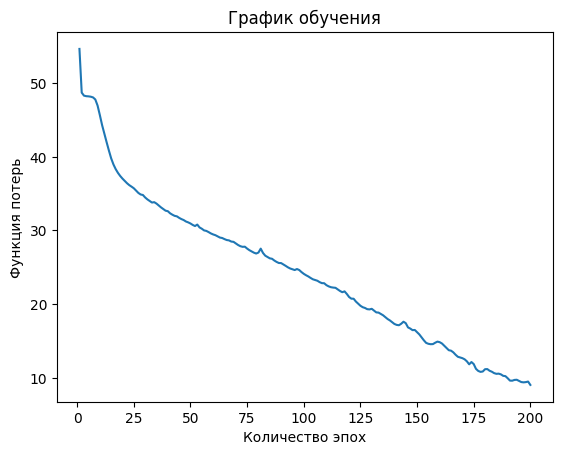

In [26]:
# Your plot code here

plt.plot(range(1, EPOCHS + 1), history)
plt.xlabel('Количество эпох')
plt.ylabel('Функция потерь')
plt.title('График обучения')
plt.show()


После одинакового количества эпох значение функции потерь LSTM ниже, чем у Vanilla RNN. Функция потерь LSTM с увеличением количества эпох стремится к 0, тогда как в случае ванильной RNN в какой-то момент может практически "застревает" на определенном значении и/или вести себя нестабильно - то падает, потом растет, опять падает и т.д. Вероятно, это связано с проблемой затухающего градиента, характерного для Vanilla RNN. Также следует отметить, что ванильная RNN изначально быстрее снижает функцию потерь, тогда как у LSTN это процесс происходит плавнее.

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [ ]:
#model = torch.load('LTSM', weights_only=False)

In [43]:
# Функция для генерации текста с разной температурой
def generate_text_lstm(model, seed_text, num_generate=200, temperature=1.0, max_line_length=80):
    model.eval()  # Устанавливаем модель в режим оценки (без обучения)

    seed_text = seed_text.lower()

    generated_text = input_seq = seed_text

    # Преобразуем начальный текст в one-hot encoding
    input_one_hot = one_hot_encode(input_seq, vocab_size)
    input_tensor = torch.tensor(input_one_hot, dtype=torch.float32).unsqueeze(0).to(device)  # Добавляем размерность батча

    hidden_state = None  # Начальное скрытое состояние

    # Генерация текста
    for _ in range(num_generate):
        with torch.no_grad():  # Не обновляем градиенты
            output, hidden_state = model(input_tensor, hidden_state)  # Прогоняем модель и получаем скрытое состояние
            output = output.squeeze(0)  # Убираем лишнюю размерность

            # Применяем temperature для регулировки вероятностей
            output = output / temperature
            probabilities = torch.nn.functional.softmax(output, dim=0).cpu().numpy()

            # Выбираем символ с вероятностью
            next_idx = np.random.choice(len(probabilities), p=probabilities)
            next_char = idx_to_token[next_idx]

            # Добавляем новый символ в сгенерированный текст
            generated_text += next_char

            # Обновляем входную последовательность для следующего шага
            input_seq = input_seq[1:] + next_char  # Сдвигаем последовательность
            input_one_hot = one_hot_encode(input_seq, vocab_size)
            input_tensor = torch.tensor(input_one_hot, dtype=torch.float32).unsqueeze(0).to(device)  # Добавляем размерность батча

    return generated_text

# Функция для генерации текста с разной температурой
def generate_text_temperature(model, seed_text, temperatures=[0.1, 0.2, 0.5, 1.0, 2.0]):
    for temp in temperatures:
        print(f"\nTemperature: {temp}")
        generated_text = generate_text_lstm(model, seed_text.lower(), num_generate=200, temperature=temp)
        print(generated_text)

# Используем seed_text для начала генерации
seed_text = "To be or not to be"
generate_text_temperature(model, seed_text)



Temperature: 0.1
to be or not to bestore:
when thou be thy sweet doth my lave though note but fome theering wres the breakes state breature forsthou dot mund crease my love the strend i at truner's dise,
then i blowst thou hisks my lov

Temperature: 0.2
to be or not to bestong,
who hard ever frest brarted for thy wornd thou paisest ay the sile growen sight adnerverys in shee,,-in sowt ind time do wornd,
or less' with time's freme i conse which hourd nthershe whin love

Temperature: 0.5
to be or not to beporte;
which hady streakss stile doth mistress'd your all goost my give thee in slell not to kild thut with fremous is a he lowge my dostoreing,
whith uthers somf anlears'd mish thel ruck doth plure t

Temperature: 1.0
to be or not to bebrow;
when i barmorig, and uppiny gives mine is screnel my priseace of see muster's swort ofress pave whon sto fayt nove in whish thy gouknels dibpheart despice,
but far your shifkst,
os lev'f coumpic

Temperature: 2.0
to be or not to benstaige.
b'd gui

Результаты текстовой генерации с разными значениями температуры демонстрируют влияние "температуры" на творческую составляющую создаваемого текста.

При температуре 0.1 текст выглядит наиболее структурированным и использует шаблоны из обучающего текста. Текст по структуре близок к исходному и ограничен в вариативности.

При температуре 0.2 текст сохраняет повторяемость, но начинают появляться  легкие вариации.

При температуре 0.5 заметно больше разнообразия и креативности, хотя текст по-прежнему близок к исходной манере. Появляются новые комбинации символов.

Temperature: 1.0
При температуре 1.0 текст становится гораздо менее предсказуемым, появляются бессмысленные сочетания символов.

Temperature: 2.0
Температура 2.0 полностью нарушает структуру исходного текста, создавая хаотичный набор символов и слов. Появляются "бессмысленные" слова - случайный набор символов.

Вывод: температура определяет соотношение консервативности и творческой составляющей генерируемого текста. Низкие температуры (0.1 и 0.2) подходят для стабильного и последовательного текста, высокие температуры (1.0 и 2.0) — для большей креативности и экспериментов. Оптимальное сочетание осмысленности и вариативности достигается при температуре 0.5.

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [45]:
# Saving and loading code here
# Сохранение модели
torch.save(model, 'model.pth')
print('Модель сохранена в файл: model.pth')

# Загрузка модели
model_loaded = torch.load('model.pth', weights_only=False)
model_loaded.eval()  # Переводим модель в режим оценки
print('Модель загружена и переведена в режим оценки')
print()
# Генерация текста загруженной моделью
seed_text = "To be or not to be"
print(generate_text_lstm(model_loaded, seed_text, num_generate=400, temperature=0.5))

Модель сохранена в файл: model.pth
Модель загружена и переведена в режим оценки

to be or not to bestore:
when thou bless's of time, a chirt,
be thy sweet thou with mysur in my hine dith my love eart of scond be.
with tootuul though de this price, to breakting the cporn dother's world, all lave in aguires no berow,
that whit be my diep my, ore with ingre surmon shay preass and stold purstion for hear times which my love gir doth live all myold gur thee, which my love lif lovs my shalg i am not 


### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a>
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)